# 0. Import Libraries and Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Inspect Dataset

In [2]:
file_path = 'mxmh_survey_results.csv'
df = pd.read_csv(file_path)

print("Data Loaded. Initial Info:")
df.info()
print("\nInitial Statistics (Before Cleaning):")
print(df.describe())

Data Loaded. Initial Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    object 
 5   Instrumentalist               732 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     736 non-null    object 
 8   Exploratory                   736 non-null    object 
 9   Foreign languages             732 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    object 
 12  Frequency [Country]           736 non

# 2. Clean Dataset for Analysis

In [3]:
columns_to_drop = ['Timestamp', 'Permissions']
df = df.drop(columns=columns_to_drop)

duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"Found and removed {duplicate_count} duplicate rows.")
    df = df.drop_duplicates()
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [4]:
df['BPM'] = df['BPM'].apply(lambda x: x if (x >= 40 and x <= 220) else np.nan)
df['Age'] = df['Age'].apply(lambda x: x if (x >= 10 and x <= 100) else np.nan)
df['Hours per day'] = df['Hours per day'].apply(lambda x: x if (x >= 0 and x <= 24) else np.nan)

In [5]:
mean_bpm = df['BPM'].mean()
df['BPM'] = df['BPM'].fillna(mean_bpm)
print(f"Filled 'BPM' nulls with corrected mean: {mean_bpm:.2f}")

mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)
print(f"Filled 'Age' nulls with corrected mean: {mean_age:.2f}")

mean_hours = df['Hours per day'].mean()
df['Hours per day'] = df['Hours per day'].fillna(mean_hours)
print(f"Filled 'Hours per day' nulls with corrected mean: {mean_hours:.2f}")

Filled 'BPM' nulls with corrected mean: 123.76
Filled 'Age' nulls with corrected mean: 25.21
Filled 'Hours per day' nulls with corrected mean: 3.57


In [6]:
categorical_cols_to_fill = ['While working', 'Instrumentalist', 'Composer', 'Foreign languages', 'Primary streaming service', 'Music effects']

for col in categorical_cols_to_fill:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled nulls in '{col}' with mode: '{mode_val}'")

Filled nulls in 'While working' with mode: 'Yes'
Filled nulls in 'Instrumentalist' with mode: 'No'
Filled nulls in 'Composer' with mode: 'No'
Filled nulls in 'Foreign languages' with mode: 'Yes'
Filled nulls in 'Primary streaming service' with mode: 'Spotify'
Filled nulls in 'Music effects' with mode: 'Improve'


In [7]:
print("\nCleaning Complete. Final Info:")
df.info()
print("\nFinal Statistics (After Cleaning):")
print(df.describe())


Cleaning Complete. Final Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           736 non-null    float64
 1   Primary streaming service     736 non-null    object 
 2   Hours per day                 736 non-null    float64
 3   While working                 736 non-null    object 
 4   Instrumentalist               736 non-null    object 
 5   Composer                      736 non-null    object 
 6   Fav genre                     736 non-null    object 
 7   Exploratory                   736 non-null    object 
 8   Foreign languages             736 non-null    object 
 9   BPM                           736 non-null    float64
 10  Frequency [Classical]         736 non-null    object 
 11  Frequency [Country]           736 non-null    object 
 12  Frequency [EDM]               73

# 3. Visualizing the Dataset for Verification of Data Cleaning

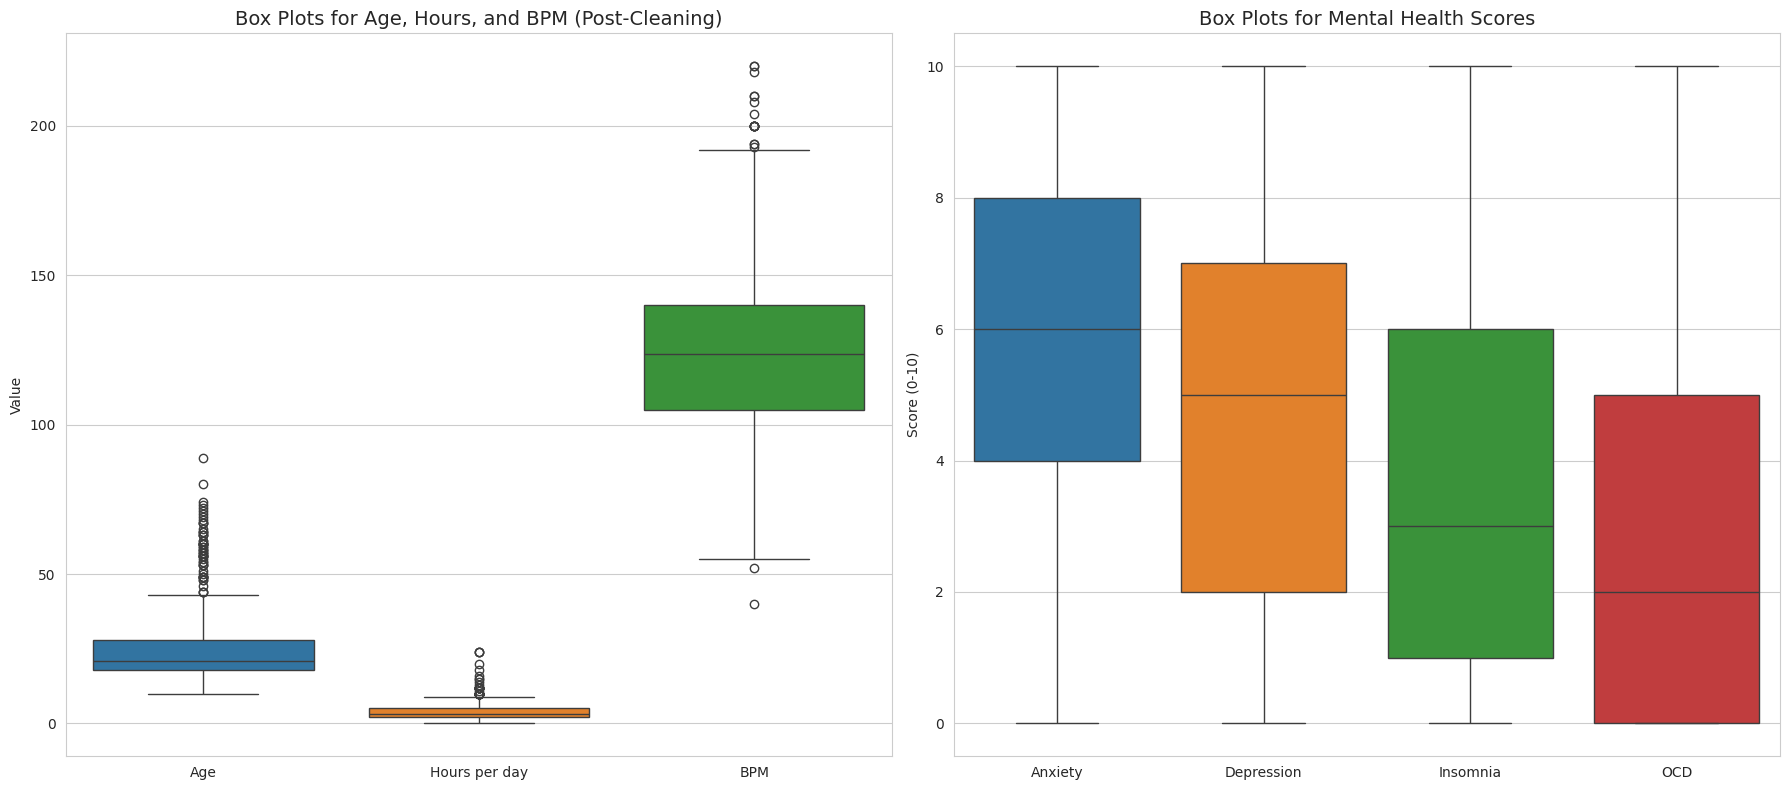

In [8]:
plt.figure(figsize=(18, 8))
sns.set_style("whitegrid")

plt.subplot(1, 2, 1)
cols_to_plot = df[['Age', 'Hours per day', 'BPM']]
sns.boxplot(data=cols_to_plot)
plt.title('Box Plots for Age, Hours, and BPM (Post-Cleaning)', fontsize=14)
plt.ylabel("Value")

plt.subplot(1, 2, 2)
mental_health_cols = df[['Anxiety', 'Depression', 'Insomnia', 'OCD']]
sns.boxplot(data=mental_health_cols)
plt.title('Box Plots for Mental Health Scores', fontsize=14)
plt.ylabel("Score (0-10)")

plt.tight_layout()
plt.show()

### Verification of Data Cleaning

These box plots serve as a final check to ensure our numerical data is clean and free of major errors.

* **Plot 1: Age, Hours, and BPM (Post-Cleaning)**
    This plot shows the distribution for our main numerical columns. Most importantly, it visually confirms that the extreme outliers in `BPM` (like the 1 billion value) have been removed, and the data is now centered around a realistic mean (around 124 BPM). The `Age` and `Hours per day` columns also show sensible distributions.

* **Plot 2: Mental Health Scores**
    This plot compares the distributions for the four self-reported mental health metrics. Since they all share the same 0-10 scale, we can easily compare them. We can see the median, quartiles, and range for each score, which helps in understanding the general mental health profile of the survey respondents.

# 4. Download the Dataset

In [9]:
output_filename = 'cleaned_music_survey_results.xlsx'
df.to_excel(output_filename, index=False)

print(f"Successfully saved cleaned data to {output_filename}")

Successfully saved cleaned data to cleaned_music_survey_results.xlsx
